# project_04_symmetric_nanocage — all notebooks (00→05) in one

This is a **convenience copy** that concatenates the six standalone notebooks in order so you can run the whole project top-to-bottom in a single Colab session. The individual notebooks (`00_setup.ipynb` … `05_validation_plan.ipynb`) remain in this folder and are the canonical deliverables. Sections are separated by dividers; each section keeps its own setup/`import` cells (re-running them is harmless). All synthetic numbers are still labeled `EXAMPLE_DATA`.

---

## ▶︎ Section 1 / 6 — `00_setup.ipynb`

---

# 00 · Environment Setup — De Novo Protein Design Capstone

This is the **shared setup notebook** every project starts from. Run it top to bottom
*once per Colab session*. It:

1. detects your GPU and warns if you're on a weak/absent one,
2. installs a light, pinned core toolset (Biopython, py3Dmol, foldseek-less utilities),
3. optionally installs heavier tools (ColabFold, ESMFold) on demand,
4. prints exact versions for your `LOG.md` (reproducibility is graded).

> **Compute reality.** A free Colab **T4** runs ColabFold, ESMFold, ProteinMPNN, and small
> RFdiffusion jobs. **BindCraft / RFantibody / large RFdiffusion** want an **A100** (Colab Pro+
> or a cluster). Each project's `MANUAL.md` states its tier. Don't fight a T4 to do an A100 job —
> plan your batch sizes around it.

## 1 · GPU & environment check

In [1]:
import subprocess, sys, platform, textwrap

def sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())

gpu = sh("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null")
if gpu:
    print("GPU    :", gpu)
    name = gpu.lower()
    if "t4" in name:
        print(textwrap.fill(
            "NOTE: T4 detected. Good for ColabFold/ESMFold/ProteinMPNN/small RFdiffusion. "
            "For BindCraft/RFantibody/large diffusion, switch to A100 (Colab Pro+) or a cluster.", 88))
    elif any(x in name for x in ("a100", "l4", "v100")):
        print("NOTE: capable GPU — heavier tools (BindCraft/RFantibody) are feasible.")
else:
    print("GPU    : NONE FOUND")
    print(textwrap.fill(
        "WARNING: No GPU. Go to Runtime → Change runtime type → Hardware accelerator → GPU. "
        "Structure prediction on CPU is impractically slow.", 88))

Python : 3.11.15
Platform: Linux-6.18.5-x86_64-with-glibc2.39
GPU    : NONE FOUND
Structure prediction on CPU is impractically slow.


## 2 · Pinned core install (fast, T4-friendly)

These are light and used across every project. Pins are conservative; bump them in your repo if needed and **log it**.

In [2]:
# Core utilities used in every project. Quiet + pinned.
%pip -q install biopython==1.84 py3Dmol==2.4.0 numpy pandas matplotlib seaborn tqdm requests 2>/dev/null
print("Core install done.")

Note: you may need to restart the kernel to use updated packages.
Core install done.


In [3]:
# Version stamp — copy this block's output into your LOG.md for reproducibility.
import importlib, datetime
mods = ["Bio", "py3Dmol", "numpy", "pandas", "matplotlib", "seaborn", "tqdm", "requests"]
print("# Environment stamp", datetime.datetime.utcnow().isoformat(timespec="seconds"), "UTC")
for m in mods:
    try:
        v = importlib.import_module(m).__version__
    except Exception:
        v = "n/a"
    print(f"{m:14s} {v}")

# Environment stamp 2026-06-24T03:14:43 UTC
Bio            1.84
py3Dmol        2.4.0


numpy          2.4.6


pandas         3.0.3
matplotlib     3.11.0


seaborn        0.13.2
tqdm           4.68.3
requests       2.33.1


## 3 · Heavy tools — install *on demand*

Don't install these unless your project needs them this session (they're slow to set up).
Each is wrapped in a function so you only pay the cost when you call it.

In [4]:
def install_colabfold():
    """ColabFold (AF2). ~3–5 min on first install. T4 OK."""
    import subprocess
    subprocess.run("pip -q install 'colabfold[alphafold-minus-jax]'", shell=True)
    # On Colab, the standard route is the localcolabfold installer or the ColabFold notebook;
    # here we expose the pip route. If it fails, fall back to the official ColabFold notebook
    # and import your sequences. Log whichever path you used.
    print("ColabFold install attempted. Verify with: from colabfold.batch import run")

def install_esmfold():
    """ESMFold via HuggingFace transformers. T4 OK for <~400 aa."""
    import subprocess
    subprocess.run("pip -q install 'transformers>=4.40' accelerate", shell=True)
    print("ESMFold deps installed. Load with transformers EsmForProteinFolding.")

print("Helpers ready: install_colabfold(), install_esmfold().")

Helpers ready: install_colabfold(), install_esmfold().


## 4 · Reproducibility helpers

Call `set_seeds()` at the top of every run, and use `log()` to append to your `LOG.md`.

In [5]:
import os, random
import numpy as np

def set_seeds(seed: int = 0):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    print(f"seeds set to {seed}")

def log(msg: str, path: str = "LOG.md"):
    import datetime
    stamp = datetime.datetime.utcnow().isoformat(timespec="seconds")
    with open(path, "a") as fh:
        fh.write(f"- {stamp}Z · {msg}\n")
    print("logged:", msg)

set_seeds(0)
log("Ran 00_setup; environment stamped.")

seeds set to 0
logged: Ran 00_setup; environment stamped.


## 5 · (Optional) Mount Google Drive for persistence

Colab sessions are ephemeral. Mount Drive to keep your `results/` and design pools between sessions.

In [6]:
# from google.colab import drive
# drive.mount("/content/drive")
# WORKDIR = "/content/drive/MyDrive/denovo_capstone/project_XX"
# import os; os.makedirs(WORKDIR, exist_ok=True); os.chdir(WORKDIR)
print("Uncomment to mount Drive and set your working directory.")

Uncomment to mount Drive and set your working directory.


---
**Next:** open `01_define_and_explore.ipynb`. Keep this session alive — re-running `00_setup`
each new session is normal. Record every version and seed in `LOG.md`.

---

## ▶︎ Section 2 / 6 — `01_define_and_explore.ipynb`

---

# 01 · Define & Explore — symmetric assembly concepts + the design plumbing

**Standard slot:** *define & explore.* **For Project 04 this means:** pin down the symmetry
concepts (symmetric contigs, tied positions, oligomeric-state error) and the three metrics that
judge a symmetric design, then stand up `sym_tools` and run a small **C3** end-to-end as your
"hello-world" (D0).

Run `00_setup.ipynb` first in this session.

## The concepts, precisely

- **Symmetric contig** — the per-subunit shape spec given to RFdiffusion symmetric mode. You
  describe ONE subunit (the asymmetric unit); the point group (`C3`/`C4`/`D2`) replicates it.
- **Tied positions** — in ProteinMPNN, residues forced to decode to the SAME amino acid across
  all symmetry-related subunits. Tying makes the assembly symmetric in *sequence*, not just
  backbone — without it, a 'symmetric' design is a fiction.
- **Oligomeric-state error (wrong-oligomer)** — the central failure mode: a subunit designed for
  C3 may instead prefer a dimer or tetramer. The in-silico tell is when the sequence *also*
  scores well as the wrong order (we model that explicitly in notebook 04).

## The metrics, precisely

| Metric | Range | Means | Does **not** mean |
|--------|-------|-------|-------------------|
| subunit scRMSD | Å | designed-vs-predicted Cα-RMSD of **one subunit** | that the assembly forms |
| interface pAE | Å | inter-chain predicted aligned error at the interface (< 10 good) | the *right* oligomer / a guarantee |
| symmetry RMSD | Å | does the predicted assembly **close** into the target point group? | stability / binding |
| pLDDT | 0–100 | per-residue *local* confidence | thermostability / assembly |
| interface energy | REU | interface-energy proxy (more negative = better) | a hard pass/fail |

Write your own one-paragraph definitions in `D0` — including the 'does not mean' column. The
single most important honesty point: **interface pAE is necessary, not sufficient** — only nsEM /
SEC-MALS / native-MS confirm the actual oligomeric state.

## Setup paths

In [7]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_04_symmetric_nanocage/notebooks


## Stand up `sym_tools`

`scripts/sym_tools.py` exposes three functions: `generate_symmetric(...)`,
`tied_mpnn(...)`, and `multimer_predict(...)`. The real backends (symmetric RFdiffusion,
tied ProteinMPNN, AF2-Multimer) need GPU + heavy installs and an **A100** for a full campaign
(see `MANUAL.md` §2); a deterministic **mock** backend lets you build and test the plumbing
first. **Never report mock numbers as real** — they are SYNTHETIC (`EXAMPLE_DATA`).

In [8]:
from sym_tools import (generate_symmetric, tied_mpnn, multimer_predict,
                       symmetric_contig, tied_positions, SYMMETRY_ORDER)

print("symmetries this project supports (order = # subunits):")
for s in ["C3", "C4", "D2"]:
    print(f"  {s}: {SYMMETRY_ORDER[s]} subunits   example contig = {symmetric_contig(s, 60)!r}")

symmetries this project supports (order = # subunits):
  C3: 3 subunits   example contig = '60-60'
  C4: 4 subunits   example contig = '60-60'
  D2: 4 subunits   example contig = '60-60'


### Tied positions — what symmetry actually means in the sequence

`tied_positions(subunit_length, n_subunits)` returns, for each residue of the asymmetric unit,
the global indices across all chains that must share one amino acid. This is the bookkeeping
ProteinMPNN needs to design a genuinely symmetric sequence.

In [9]:
groups = tied_positions(subunit_length=6, n_subunits=3)  # tiny example for readability
print("residue -> tied chain copies (global indices), C3 with a 6-residue subunit:")
for i, g in enumerate(groups):
    print(f"  subunit residue {i} ties global indices {g}")

residue -> tied chain copies (global indices), C3 with a 6-residue subunit:
  subunit residue 0 ties global indices [0, 6, 12]
  subunit residue 1 ties global indices [1, 7, 13]
  subunit residue 2 ties global indices [2, 8, 14]
  subunit residue 3 ties global indices [3, 9, 15]
  subunit residue 4 ties global indices [4, 10, 16]
  subunit residue 5 ties global indices [5, 11, 17]


## Hello-world: a small C3 (mock)

Generate one small **C3** backbone, design a tied sequence for it, and predict the assembly —
the whole pipeline in miniature. We use the **mock** backend so it runs anywhere; switch to the
real backends on an A100 (see the note below the cell).

In [10]:
# Start with the mock backend to confirm the plumbing, THEN switch tool="rfdiffusion"/"proteinmpnn"/"af2".
asm = generate_symmetric("C3", length=60, n=1, tool="mock")[0]
print("backbone:", asm.as_row())

seqs = tied_mpnn(asm, "C3", n_seqs=2, tool="mock")
print("\ntied sequences (both subunits share each sequence):")
for s in seqs:
    print(" ", s)

score = multimer_predict(seqs[0], "C3", tool="mock")
print("\nAF2-Multimer readout (SYNTHETIC — mock):")
print(" ", score.as_row())

backbone: {'assembly_id': 'EXAMPLE_DATA_C3_60_000', 'symmetry': 'C3', 'subunit_length': 60, 'n_subunits': 3, 'backbone_pdb': None, 'contig': '60-60', 'tool': 'mock', 'note': 'SYNTHETIC — mock backbone, not a real RFdiffusion design'}

tied sequences (both subunits share each sequence):
  SKTDCWANKLYHKSMDTNNWKLHHYGEQCWHWSKTDCWANKLYHKSMDTNNWKLHHYGEQ
  PNEGMFSFCMHFAAWWSTHMKFSFMDLIYPAGPNEGMFSFCMHFAAWWSTHMKFSFMDLI

AF2-Multimer readout (SYNTHETIC — mock):
  {'symmetry': 'C3', 'subunit_scrmsd': 4.43, 'interface_pae': 19.63, 'symmetry_rmsd': 5.24, 'plddt': 85, 'interface_energy': -43, 'predicted_order': 4, 'tool': 'mock', 'ok': True, 'error': 'SYNTHETIC — mock AF2-Multimer readout, not a real prediction'}


### Switch to the real backends

Once `00_setup` has installed symmetric RFdiffusion / ProteinMPNN / ColabFold this session
(A100 recommended), change `tool="mock"` to the real tool names. ESMFold-style triage is not
enough here — assembly judgement needs the **multimer** predictor. Record runtime + the
RFdiffusion/ColabFold commit pins in `LOG.md`.

In [11]:
# Uncomment on an A100 once the real tools are installed in 00_setup:
# asm = generate_symmetric("C3", length=60, n=1, tool="rfdiffusion")[0]
# seqs = tied_mpnn(asm, "C3", n_seqs=2, tool="proteinmpnn")
# score = multimer_predict(seqs[0], "C3", tool="af2")
# assert score.ok, score.error
print("Ready — flip the tools to the real backends on an A100 (see MANUAL §2).")

Ready — flip the tools to the real backends on an A100 (see MANUAL §2).


## Visualize a structure (py3Dmol)

Use this to eyeball any predicted assembly PDB once you have one (color by chain to see the
symmetry). On the mock backend there is no PDB yet — this is the placeholder you'll fill on
Colab.

In [12]:
import py3Dmol

def show_assembly(pdb_path_or_str, is_path=True):
    """Show a multi-chain assembly colored by chain (so symmetry is visible)."""
    data = open(pdb_path_or_str).read() if is_path else pdb_path_or_str
    view = py3Dmol.view(width=520, height=420)
    view.addModel(data, "pdb")
    view.setStyle({"cartoon": {"colorscheme": "chain"}})
    view.zoomTo()
    return view.show()

# Example (after a real multimer prediction):
# show_assembly(score_pdb_path)
print("show_assembly(pdb_path) ready — color-by-chain reveals the point group.")

show_assembly(pdb_path) ready — color-by-chain reveals the point group.


## D0 checklist
- [ ] One-paragraph definition of each metric **with** its 'does not mean' note (esp. interface pAE = necessary-not-sufficient).
- [ ] `sym_tools` imported; tied-position layout understood for your target symmetry.
- [ ] One reproduced small-C3 run (mock, then real on an A100 if available) with its three metrics printed.
- [ ] Problem statement with measurable success criteria + controls.
- [ ] `LOG.md` entry: tool version / commit pins, GPU, runtime, seed.

**Next:** `02_generate.ipynb` — the C3/C4/D2 design campaign.

---

## ▶︎ Section 3 / 6 — `02_generate.ipynb`

---

# 02 · Campaign — generate C3/C4/D2 assemblies + tied sequence design

**Standard slot:** *design campaign.* **For Project 04 this means:** generate **hundreds** of
symmetric backbones across **C3 / C4 / D2** with symmetric contigs, design each with **tied**
ProteinMPNN, and write `results/assemblies.csv` (D2). *Diversity before filtering* — generate
broadly now; triage in notebook 03.

Runs on the **mock** backend so it executes anywhere; the **real** symmetric RFdiffusion call is
shown (commented) with the A100 note. A free T4 realistically runs only a small C3 demo.

## Setup paths

In [13]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_04_symmetric_nanocage/notebooks


## Version-verify the pinned upstreams (tools change)

Symmetric RFdiffusion, ColabDesign, and SymDesign move fast. Before relying on a pinned
version, confirm the upstream repo still exists. We pin a commit/tag in the comment; **update
the pin and log it** if the check fails or the API changed.

In [14]:
import requests

# Pinned upstreams for this project — PIN A SPECIFIC COMMIT/TAG in your repo; tools change.
UPSTREAMS = {
    # RFdiffusion (symmetric mode). Pin example: a release tag or commit SHA you tested.
    "RFdiffusion": "https://github.com/RosettaCommons/RFdiffusion",   # pin a commit/tag
    # ColabDesign — symmetric RFdiffusion + AF2 wrappers + ProteinMPNN helpers.
    "ColabDesign": "https://github.com/sokrypton/ColabDesign",        # pin a commit/tag
    # SymDesign — symmetry definitions + symmetric docking concepts (optional).
    "SymDesign":  "https://github.com/kylemeador/symdesign",          # pin a commit/tag
}
for name, url in UPSTREAMS.items():
    try:
        r = requests.head(url, allow_redirects=True, timeout=20)
        print(f"{name:12s} {url}  ->  HTTP {r.status_code}")
    except Exception as e:
        print(f"{name:12s} {url}  ->  CHECK FAILED ({e!r}) — update the pin and log it")

RFdiffusion  https://github.com/RosettaCommons/RFdiffusion  ->  HTTP 200


ColabDesign  https://github.com/sokrypton/ColabDesign  ->  HTTP 200


SymDesign    https://github.com/kylemeador/symdesign  ->  HTTP 200


## 1 · The campaign plan (symmetries × sizes)

We generate three symmetry families from `data/inputs/symmetry_defs.txt`. Scale `N_PER` up on
an A100; keep it tiny on a T4. The `mock` backend makes this loop run anywhere so you can build
the bookkeeping before paying for GPU.

In [15]:
from sym_tools import generate_symmetric, tied_mpnn, SYMMETRY_ORDER
import pandas as pd

# (symmetry, subunit_length). Mirror data/inputs/symmetry_defs.txt; verify contigs for real runs.
CAMPAIGN = [("C3", 60), ("C4", 70), ("D2", 65)]
N_PER = 5          # backbones per family on the dry run; raise to 100s on an A100
N_SEQS = 4         # tied sequences per backbone
TOOL_GEN = "mock"  # -> "rfdiffusion" on an A100
TOOL_SEQ = "mock"  # -> "proteinmpnn" (tied) anywhere (MPNN is light)

for sym, L in CAMPAIGN:
    print(f"{sym}: {SYMMETRY_ORDER[sym]} subunits, subunit length {L}")

C3: 3 subunits, subunit length 60
C4: 4 subunits, subunit length 70
D2: 4 subunits, subunit length 65


## 2 · The real symmetric RFdiffusion call (for the A100 run)

This is what the `tool="rfdiffusion"` backend wraps. **Verify the flags** against your pinned
RFdiffusion release — symmetric-mode flag names have changed across versions — and run it on an
**A100/HPC** for a full campaign.

In [16]:
REAL_RFDIFFUSION_CALL = r"""
# A100 RECOMMENDED. Verify flags against the pinned RFdiffusion release before running.
./scripts/run_inference.py \
  inference.symmetry=C3 \
  'contigmap.contigs=[60-60]' \
  inference.num_designs=50 \
  inference.output_prefix=results/backbones/C3
# Then tied ProteinMPNN (light; CPU/T4 fine):
#   python protein_mpnn_run.py --pdb_path results/backbones/C3_0.pdb \
#     --tied_positions_jsonl tied.jsonl --num_seq_per_target 8 --sampling_temp 0.1
"""
print(REAL_RFDIFFUSION_CALL)


# A100 RECOMMENDED. Verify flags against the pinned RFdiffusion release before running.
./scripts/run_inference.py \
  inference.symmetry=C3 \
  'contigmap.contigs=[60-60]' \
  inference.num_designs=50 \
  inference.output_prefix=results/backbones/C3
# Then tied ProteinMPNN (light; CPU/T4 fine):
#   python protein_mpnn_run.py --pdb_path results/backbones/C3_0.pdb \
#     --tied_positions_jsonl tied.jsonl --num_seq_per_target 8 --sampling_temp 0.1



## 3 · Run the campaign (mock) → `results/assemblies.csv`

Generate backbones, design tied sequences for each, and record one row per (design × sequence).
Tied design means every symmetry-related subunit shares the sequence in that row. Switch the
`TOOL_*` flags to the real backends on an A100.

In [17]:
rows = []
for sym, L in CAMPAIGN:
    backbones = generate_symmetric(sym, length=L, n=N_PER, tool=TOOL_GEN)
    for asm in backbones:
        seqs = tied_mpnn(asm, sym, n_seqs=N_SEQS, tool=TOOL_SEQ)
        for j, seq in enumerate(seqs):
            rows.append(dict(
                assembly_id=asm.assembly_id, seq_index=j, symmetry=sym,
                n_subunits=asm.n_subunits, subunit_length=L, contig=asm.contig,
                tied=True, gen_tool=TOOL_GEN, seq_tool=TOOL_SEQ, sequence=seq))
assemblies = pd.DataFrame(rows)
assemblies.to_csv("results/assemblies.csv", index=False)
print("wrote results/assemblies.csv", assemblies.shape)
print(assemblies.groupby("symmetry")["assembly_id"].nunique().rename("n_backbones"))
assemblies.head()

wrote results/assemblies.csv (60, 10)
symmetry
C3    5
C4    5
D2    5
Name: n_backbones, dtype: int64


,assembly_id,seq_index,symmetry,n_subunits,subunit_length,contig,tied,gen_tool,seq_tool,sequence
0,EXAMPLE_DATA_C3_60_000,0,C3,3,60,60-60,True,mock,mock,SKTDCWANKLYHKSMDTNNWKLHHYGEQCWHWSKTDCWANKLYHKS...
1,EXAMPLE_DATA_C3_60_000,1,C3,3,60,60-60,True,mock,mock,PNEGMFSFCMHFAAWWSTHMKFSFMDLIYPAGPNEGMFSFCMHFAA...
2,EXAMPLE_DATA_C3_60_000,2,C3,3,60,60-60,True,mock,mock,FRRHVGRYQDVVCMFMIGELQTSMDTGGEQVVFRRHVGRYQDVVCM...
3,EXAMPLE_DATA_C3_60_000,3,C3,3,60,60-60,True,mock,mock,YICFFPPFRKQVAMHLDNNMEHAGEWDDKNHNYICFFPPFRKQVAM...
4,EXAMPLE_DATA_C3_60_001,0,C3,3,60,60-60,True,mock,mock,KDRYHYIQAWTDFVPAEGAYCNQMSYTTYFSLKDRYHYIQAWTDFV...


## 4 · An untied subset (for the tied-vs-untied benchmark in nb 04) `[extension]`

To ask whether tying actually helps, design a subset **without** tying (each chain free) and
tag it `tied=False`. In the mock backend we approximate this by perturbing the seed; on Colab,
run ProteinMPNN without the tied-positions JSON. Keep both in the pool for the comparison.

In [18]:
# Untied subset: same backbones, tied=False. (Mock approximates by reusing tied_mpnn with a tag;
# on Colab, run ProteinMPNN WITHOUT the tied_positions_jsonl to get genuinely untied chains.)
untied_rows = []
for sym, L in CAMPAIGN[:1]:  # a subset (C3) is enough for the benchmark
    backbones = generate_symmetric(sym, length=L, n=N_PER, tool=TOOL_GEN)
    for asm in backbones:
        seqs = tied_mpnn(asm, sym, n_seqs=N_SEQS, tool=TOOL_SEQ)  # placeholder for an untied run
        for j, seq in enumerate(seqs):
            untied_rows.append(dict(
                assembly_id=asm.assembly_id + "_untied", seq_index=j, symmetry=sym,
                n_subunits=asm.n_subunits, subunit_length=L, contig=asm.contig,
                tied=False, gen_tool=TOOL_GEN, seq_tool=TOOL_SEQ, sequence=seq))
import pandas as pd
pool = pd.concat([assemblies, pd.DataFrame(untied_rows)], ignore_index=True)
pool.to_csv("results/assemblies.csv", index=False)
print("pool with tied + untied:", pool.shape, "| tied counts:")
print(pool["tied"].value_counts())

pool with tied + untied: (80, 10) | tied counts:
tied
True     60
False    20
Name: count, dtype: int64


## D2 checklist
- [ ] `results/assemblies.csv`: C3/C4/D2, 100s of designs on the real run, one row per (design × sequence).
- [ ] Tied design verified (symmetry-related subunits share a sequence); an untied subset for the benchmark.
- [ ] Design log: gen/seq tool versions, RFdiffusion/ColabFold commit pins, seeds, contigs, runtimes in `LOG.md`.
- [ ] 3–4 page interim report.

**Next:** `03_filter_and_rank.ipynb` — run the shared `oligomer` filter on your assemblies.

---

## ▶︎ Section 4 / 6 — `03_filter_and_rank.ipynb`

---

# 03 · Filter & Rank — run the shared multi-layer filter (oligomer)

**Standard slot:** *filter & rank* via `shared/filtering_pipeline.py` — the same module all 25
projects use. **For Project 04** you run it with `design_type="oligomer"` so the cutoffs match
symmetric assemblies (subunit scRMSD, pLDDT, interface pAE), then add a **symmetry-RMSD** screen
on top (does it close into the intended order?).

Run `00`–`02` first so `results/assemblies.csv` exists.

## Setup paths

In [19]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_04_symmetric_nanocage/notebooks


## Load the shared filtering pipeline
This is the cohort's shared module — the `oligomer` cutoffs live in its `DEFAULT_CUTOFFS`.

In [20]:
import filtering_pipeline as fp
import pandas as pd

print("oligomer cutoffs:", fp.DEFAULT_CUTOFFS["oligomer"])

oligomer cutoffs: {'scrmsd': 2.5, 'plddt': 80, 'pae': 10}


## 1 · Predict each assembly (AF2-Multimer) and attach metrics

For each row in the pool, run `multimer_predict` to get subunit scRMSD, interface pAE, symmetry
RMSD, pLDDT, and an interface-energy proxy. Mock backend here (deterministic, SYNTHETIC); switch
to `tool="af2"` on an A100. We keep `predicted_order` so notebook 04 can study wrong-oligomer risk.

In [21]:
from sym_tools import multimer_predict

pool = pd.read_csv("results/assemblies.csv")
PRED_TOOL = "mock"   # -> "af2" on an A100

pred_rows = []
for _, r in pool.iterrows():
    s = multimer_predict(r["sequence"], r["symmetry"], tool=PRED_TOOL)
    pred_rows.append(dict(
        assembly_id=r["assembly_id"], seq_index=r["seq_index"], symmetry=r["symmetry"],
        n_subunits=r["n_subunits"], tied=r["tied"],
        subunit_scrmsd=s.subunit_scrmsd, interface_pae=s.interface_pae,
        symmetry_rmsd=s.symmetry_rmsd, plddt=s.plddt,
        interface_energy=s.interface_energy, predicted_order=s.predicted_order))
pred = pd.DataFrame(pred_rows)
pred.to_csv("results/predictions.csv", index=False)
print("wrote results/predictions.csv", pred.shape)
pred.head()

wrote results/predictions.csv (80, 11)


,assembly_id,seq_index,symmetry,n_subunits,tied,subunit_scrmsd,interface_pae,symmetry_rmsd,plddt,interface_energy,predicted_order
0,EXAMPLE_DATA_C3_60_000,0,C3,3,True,4.43,19.63,5.24,85,-43,4
1,EXAMPLE_DATA_C3_60_000,1,C3,3,True,4.08,7.28,3.27,92,-25,3
2,EXAMPLE_DATA_C3_60_000,2,C3,3,True,4.06,7.26,3.27,84,-19,3
3,EXAMPLE_DATA_C3_60_000,3,C3,3,True,3.66,14.86,1.33,79,-39,3
4,EXAMPLE_DATA_C3_60_001,0,C3,3,True,0.90,16.10,4.21,86,-16,3


## 2 · Build `fp.Design` objects (design_type='oligomer')

The filter operates on `fp.Design` records. Map the multimer metrics onto its fields:
`scrmsd` ← subunit scRMSD, `pae_interaction` ← interface pAE, `plddt` ← assembly pLDDT,
`rosetta_dG` ← interface-energy proxy. The symmetry RMSD has no native field, so we carry it in
`extra` and apply it as an extra screen after the standard layers.

In [22]:
designs = []
for _, r in pred.iterrows():
    designs.append(fp.Design(
        design_id=f"{r['assembly_id']}#{int(r['seq_index'])}",
        sequence="",                         # not needed for the confidence layers
        design_type="oligomer",
        scrmsd=r["subunit_scrmsd"],
        plddt=r["plddt"],
        pae_interaction=r["interface_pae"],
        rosetta_dG=r["interface_energy"],    # interface-energy proxy (more negative = better)
        extra={"symmetry": r["symmetry"], "n_subunits": int(r["n_subunits"]),
               "tied": bool(r["tied"]), "symmetry_rmsd": r["symmetry_rmsd"],
               "predicted_order": int(r["predicted_order"])},
    ))
print(len(designs), "Design objects built (design_type='oligomer')")

80 Design objects built (design_type='oligomer')


## 3 · Run the shared pipeline

`run_pipeline(..., design_type="oligomer")` applies the layers in order with the oligomer
cutoffs and returns a ranked DataFrame. We use layers 1 (self-consistency: subunit scRMSD +
pLDDT + interface pAE) and 3 (physics: interface energy). Layer 2 (orthogonal) needs a second
predictor's scRMSD — wire it in when you have one.

Total designs: 80
  L1 survivors: 6  (7.5%)
  L3 survivors: 6  (7.5%)


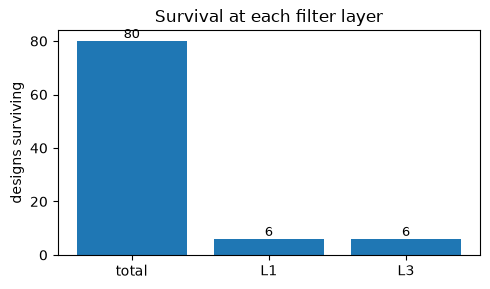

,design_id,design_type,layers_passed,score,scrmsd,plddt,pae_interaction,rosetta_dG,tm_to_pdb
0,EXAMPLE_DATA_D2_65_004#2,oligomer,3,4.6975,1.03,95,4.23,-44,None
1,EXAMPLE_DATA_C4_70_000#1,oligomer,3,4.1117,1.10,96,4.30,-18,None
2,EXAMPLE_DATA_C4_70_004#1,oligomer,3,3.1008,2.15,84,9.35,-47,None
3,EXAMPLE_DATA_C3_60_001#1,oligomer,3,3.0617,2.30,95,5.50,-31,None
4,EXAMPLE_DATA_C3_60_001_untied#1,oligomer,3,3.0617,2.30,95,5.50,-31,None
5,EXAMPLE_DATA_C4_70_003#3,oligomer,3,2.4167,2.32,80,9.52,-24,None
6,EXAMPLE_DATA_C4_70_002#0,oligomer,0,3.9067,1.16,79,4.36,-57,None
7,EXAMPLE_DATA_C3_60_002#1,oligomer,0,3.1983,0.98,70,8.18,-33,None
8,EXAMPLE_DATA_C3_60_002_untied#1,oligomer,0,3.1983,0.98,70,8.18,-33,None
9,EXAMPLE_DATA_C3_60_003#1,oligomer,0,3.1200,1.35,97,12.55,-50,None


In [23]:
df_ranked = fp.run_pipeline(designs, design_type="oligomer", use_layers=(1, 3))
df_ranked.to_csv("results/ranked.csv", index=False)
top = fp.report(df_ranked, top_n=10, save_prefix="results/proj04")
top

## 4 · Extra screen — symmetry RMSD (does it close into the target order?)

The standard layers check the subunit and the interface; the **symmetry RMSD** asks whether the
whole assembly closes into the intended point group. A design can pass interface pAE yet fail
here (confident interface, wrong global arrangement). Apply it as an explicit gate and report
how many survivors it removes.

In [24]:
import numpy as np
SYM_RMSD_CUTOFF = 2.0   # Å; project-specific — calibrate against your reference homo-oligomers

# Pull the symmetry-RMSD and symmetry label out of `extra` onto the ranked frame.
df_ranked["symmetry_rmsd"] = df_ranked["extra"].apply(
    lambda e: e.get("symmetry_rmsd") if isinstance(e, dict) else np.nan)
df_ranked["symmetry"] = df_ranked["extra"].apply(
    lambda e: e.get("symmetry") if isinstance(e, dict) else None)
passed_layers = df_ranked[df_ranked["layers_passed"] >= 1]
sym_clean = passed_layers[passed_layers["symmetry_rmsd"] <= SYM_RMSD_CUTOFF]
print(f"passed standard layers: {len(passed_layers)}")
print(f"of those, symmetry-RMSD-clean (<= {SYM_RMSD_CUTOFF} Å): {len(sym_clean)}")
print("  -> the gap is designs with a confident interface but the WRONG global arrangement.")

passed standard layers: 6
of those, symmetry-RMSD-clean (<= 2.0 Å): 3
  -> the gap is designs with a confident interface but the WRONG global arrangement.


## 5 · Survival-at-each-layer + assembly-success rate (honest accounting)

Report how many designs pass each layer, **per symmetry**. The assembly-success rate is the
fraction passing the full filter *including* the symmetry-RMSD screen. Expect it to be modest
and to differ by symmetry order — report it, don't hide it.

In [25]:
# Per-symmetry success accounting (mock numbers are SYNTHETIC EXAMPLE_DATA).
# (df_ranked["symmetry"] and sym_clean were derived in the symmetry-RMSD cell above.)
gen = df_ranked.groupby("symmetry").size().rename("generated")
passed = df_ranked[df_ranked["layers_passed"] >= 1].groupby("symmetry").size().rename("passed_layers")
clean = sym_clean.groupby("symmetry").size().rename("symmetry_clean")
acct = pd.concat([gen, passed, clean], axis=1).fillna(0).astype(int)
acct["success_rate"] = (acct["symmetry_clean"] / acct["generated"]).round(3)
print("assembly-success accounting per symmetry (EXAMPLE_DATA on the mock backend):")
print(acct)

assembly-success accounting per symmetry (EXAMPLE_DATA on the mock backend):
          generated  passed_layers  symmetry_clean  success_rate
symmetry                                                        
C3               40              2               2          0.05
C4               20              3               1          0.05
D2               20              1               0          0.00


## D3 (part 1) checklist
- [ ] `results/ranked.csv` produced by the **shared** module with `design_type="oligomer"`.
- [ ] Symmetry-RMSD screen applied on top; symmetry-clean survivors reported.
- [ ] Survival-at-each-layer + per-symmetry assembly-success rate reported (N pass / N generated).
- [ ] Mapping assumptions (which metric → which `Design` field) written down.

**Next:** `04_validate.ipynb` — symmetry-order-vs-success, tied-vs-untied, wrong-oligomer analysis.

---

## ▶︎ Section 5 / 6 — `04_validate.ipynb`

---

# 04 · Validate — symmetry-order vs success, tied vs untied, wrong-oligomer risk

**Standard slot:** *validate (in silico).* **For Project 04 this is the core analysis:** does
success depend on symmetry order? Does tying the sequence help? And — the scientific heart —
do top designs survive a **wrong-oligomer** check, or do they also score well as the wrong
order? (D3.)

Needs `results/predictions.csv` from notebook 03.

## Setup paths

In [26]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_04_symmetric_nanocage/notebooks


## 1 · Symmetry order vs success

Compute the pass rate per symmetry under the `oligomer` filter (subunit scRMSD ≤ 2.5, pLDDT ≥ 80,
interface pAE ≤ 10) plus the symmetry-RMSD gate. Higher-order / dihedral assemblies are usually
harder — report the rates with N. (Mock numbers are SYNTHETIC `EXAMPLE_DATA`.)

In [27]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

pred = pd.read_csv("results/predictions.csv")
C = dict(scrmsd=2.5, plddt=80, pae=10, sym=2.0)   # oligomer cutoffs + symmetry-RMSD gate

def passes(r):
    return (r["subunit_scrmsd"] <= C["scrmsd"] and r["plddt"] >= C["plddt"]
            and r["interface_pae"] <= C["pae"] and r["symmetry_rmsd"] <= C["sym"])
pred["pass"] = pred.apply(passes, axis=1)

by_sym = pred.groupby("symmetry").agg(n=("pass", "size"), n_pass=("pass", "sum"))
by_sym["success_rate"] = (by_sym["n_pass"] / by_sym["n"]).round(3)
print("symmetry order vs success (EXAMPLE_DATA on mock):")
print(by_sym)

symmetry order vs success (EXAMPLE_DATA on mock):
           n  n_pass  success_rate
symmetry                          
C3        40       2          0.05
C4        20       1          0.05
D2        20       0          0.00


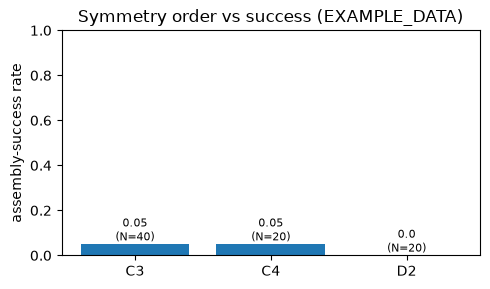

In [28]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(by_sym.index.astype(str), by_sym["success_rate"])
for i, (rate, n) in enumerate(zip(by_sym["success_rate"], by_sym["n"])):
    ax.text(i, rate, f"{rate}\n(N={n})", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("assembly-success rate"); ax.set_ylim(0, 1)
ax.set_title("Symmetry order vs success (EXAMPLE_DATA)")
plt.tight_layout(); plt.savefig("results/symmetry_vs_success.png", dpi=150); plt.show()

## 2 · Tied vs untied sequence design `[extension]`

Does tying symmetry-related positions improve the pass rate? Compare the tied and untied subsets
(the latter built in notebook 02). The expectation is that tying helps — untied chains can
diverge and break symmetry — but **report what your data actually show**, with N.

In [29]:
if "tied" in pred.columns and pred["tied"].nunique() > 1:
    by_tied = pred.groupby("tied").agg(n=("pass", "size"), n_pass=("pass", "sum"))
    by_tied["success_rate"] = (by_tied["n_pass"] / by_tied["n"]).round(3)
    print("tied vs untied (EXAMPLE_DATA on mock):")
    print(by_tied)
else:
    print("Need both tied and untied designs in the pool (see notebook 02 step 4).")

tied vs untied (EXAMPLE_DATA on mock):
        n  n_pass  success_rate
tied                           
False  20       1         0.050
True   60       2         0.033


## 3 · Wrong-oligomer risk analysis `[extension]`

The central failure mode. Two complementary views:
1. **Predicted-order mismatch** — `predicted_order` is the oligomeric order the predictor most
   prefers; if it differs from the intended `n_subunits`, the design is at risk.
2. **Alternative-state modelling** — predict the *same sequence* as other orders and check
   whether it scores comparably; a design that is 'happy' as the wrong order is a red flag.

On Colab, run `multimer_predict` with sequences arranged as different chain counts; here we use
the mock `predicted_order` and a small alternative-state sweep.

In [30]:
# View 1: predicted-order mismatch.
pred["wrong_oligomer_risk"] = pred["predicted_order"] != pred["n_subunits"]
risk = pred.groupby("symmetry")["wrong_oligomer_risk"].mean().round(3)
print("fraction of designs whose PREFERRED order != intended order (EXAMPLE_DATA):")
print(risk)
print("\n-> high values mean the symmetry is hard to hit cleanly; treat those picks with caution.")

fraction of designs whose PREFERRED order != intended order (EXAMPLE_DATA):
symmetry
C3    0.20
C4    0.20
D2    0.25
Name: wrong_oligomer_risk, dtype: float64

-> high values mean the symmetry is hard to hit cleanly; treat those picks with caution.


In [31]:
# View 2: alternative-state sweep for the top design (model the sequence as several orders).
from sym_tools import multimer_predict, SYMMETRY_ORDER

pool = pd.read_csv("results/assemblies.csv")
top_row = pool.iloc[0]
seq, intended = top_row["sequence"], top_row["symmetry"]
ALT_STATES = ["C2", "C3", "C4", "D2"]   # candidate alternative orders to test
print(f"top design: intended {intended} ({SYMMETRY_ORDER[intended]} subunits)\n")
print(f"{'state':6s} {'order':6s} {'iface_pae':10s} {'sym_rmsd':9s}")
for st in ALT_STATES:
    s = multimer_predict(seq, st, tool="mock")   # -> tool="af2" on an A100
    flag = "  <-- intended" if st == intended else ""
    print(f"{st:6s} {SYMMETRY_ORDER[st]:<6d} {s.interface_pae:<10.2f} {s.symmetry_rmsd:<9.2f}{flag}")
print("\nRed flag: an ALTERNATIVE state scores as well as (or better than) the intended one.")

top design: intended C3 (3 subunits)

state  order  iface_pae  sym_rmsd 
C2     2      10.03      2.42     
C3     3      19.63      5.24       <-- intended
C4     4      7.16       0.77     
D2     4      15.75      1.71     

Red flag: an ALTERNATIVE state scores as well as (or better than) the intended one.


## 4 · Cross-metric view (interface pAE vs symmetry RMSD)

Interface pAE and symmetry RMSD measure different things. Plotting them together separates the
four quadrants: clean (both good), confident-but-wrong-arrangement (good pAE, bad symmetry RMSD),
and so on. The off-diagonal cases are exactly where wrong-oligomer risk hides.

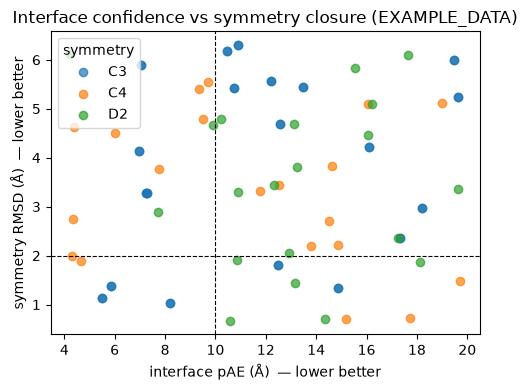

Bottom-left quadrant = clean. Bottom-right of the vertical line = confident interface, wrong closure.


In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
for sym, g in pred.groupby("symmetry"):
    ax.scatter(g["interface_pae"], g["symmetry_rmsd"], label=str(sym), alpha=0.7)
ax.axvline(C["pae"], ls="--", lw=0.8, color="k")
ax.axhline(C["sym"], ls="--", lw=0.8, color="k")
ax.set_xlabel("interface pAE (Å)  — lower better"); ax.set_ylabel("symmetry RMSD (Å)  — lower better")
ax.set_title("Interface confidence vs symmetry closure (EXAMPLE_DATA)"); ax.legend(title="symmetry")
plt.tight_layout(); plt.savefig("results/pae_vs_symrmsd.png", dpi=150); plt.show()
print("Bottom-left quadrant = clean. Bottom-right of the vertical line = confident interface, wrong closure.")

## D3 (part 2) checklist
- [ ] Symmetry-order-vs-success rates with N (figure saved).
- [ ] Tied-vs-untied comparison reported honestly.
- [ ] Wrong-oligomer risk analysis: predicted-order mismatch **and** an alternative-state sweep on top picks.
- [ ] Interface-pAE-vs-symmetry-RMSD view; off-diagonal (confident-but-wrong) cases flagged.
- [ ] Failure-mode note: which symmetry is hardest, and why your top picks might still be wrong.

**Next:** `05_validation_plan.ipynb` — the nsEM/SEC-MALS plan + antigen-display extension.

---

## ▶︎ Section 6 / 6 — `05_validation_plan.ipynb`

---

# 05 · Validation Plan — nsEM / SEC-MALS / native-MS + antigen-display extension

**Standard slot:** *validation plan.* **For Project 04 this means:** turn your ranked C3/C4/D2
candidate set into a controlled **experimental plan that determines the actual oligomeric state**
(in-silico filters only enrich), plus the **assembly design report** and the epitope-graft
antigen-display extension (vaccine framing). (D4/D5.)

## Setup paths

In [33]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_04_symmetric_nanocage/notebooks


## 1 · Select the ranked candidate set (the D★ deliverable)

Take the symmetry-clean survivors from notebook 03 and assemble the ranked C3/C4/D2 candidate
set — the core of the assembly design report. Each pick carries its symmetry, the three metrics,
and its wrong-oligomer status.

In [34]:
import pandas as pd, os

pred = pd.read_csv("results/predictions.csv")
C = dict(scrmsd=2.5, plddt=80, pae=10, sym=2.0)
clean = pred[(pred["subunit_scrmsd"] <= C["scrmsd"]) & (pred["plddt"] >= C["plddt"]) &
             (pred["interface_pae"] <= C["pae"]) & (pred["symmetry_rmsd"] <= C["sym"]) &
             (pred["predicted_order"] == pred["n_subunits"])].copy()
clean["rank_score"] = (clean["plddt"]/100 + (10 - clean["interface_pae"])/10
                       + (2.5 - clean["subunit_scrmsd"]))
ranked = clean.sort_values("rank_score", ascending=False)
top_set = ranked.groupby("symmetry").head(3)   # top picks per symmetry
top_set.to_csv("results/candidate_set.csv", index=False)
print("ranked C3/C4/D2 candidate set (EXAMPLE_DATA on mock):", top_set.shape)
print(top_set[["assembly_id", "symmetry", "subunit_scrmsd", "interface_pae", "symmetry_rmsd"]].head(9))

ranked C3/C4/D2 candidate set (EXAMPLE_DATA on mock): (2, 12)
                      assembly_id symmetry  subunit_scrmsd  interface_pae  \
5          EXAMPLE_DATA_C3_60_001       C3             2.3            5.5   
65  EXAMPLE_DATA_C3_60_001_untied       C3             2.3            5.5   

    symmetry_rmsd  
5            1.13  
65           1.13  


## 2 · The experimental validation plan (oligomeric-state determination)

Generate the plan as a Markdown artifact. The key point: **interface pAE is necessary, not
sufficient** — the assays below are what actually determine the oligomeric state. Controls are
mandatory: positive = a known nanocage / a verified natural homo-oligomer of the target
symmetry; negative = a **scrambled-interface or monomeric** variant of your *own* design (must
NOT assemble); plus an unrelated-protein control.

In [35]:
plan = """# Assembly Validation Plan (Project 04 — <your name>, <date>)

Goal: determine the ACTUAL oligomeric state of the ranked C3/C4/D2 candidates.
In-silico interface pAE is necessary, not sufficient — these assays confirm the real state.

## Expression & purification
- Host: E. coli BL21(DE3), 16-18 C overnight (mammalian only if a glycosylated antigen is grafted).
- Purify by IMAC -> SEC; carry the SEC trace into characterization.

## Oligomeric-state determination (the core)
| Assay | What it tells you | Go/No-go |
|-------|-------------------|----------|
| SEC | apparent size / homogeneity | single symmetric peak at expected volume |
| SEC-MALS | ABSOLUTE molar mass -> oligomeric number | mass = n_subunits x monomer mass |
| negative-stain EM (nsEM) | assembly architecture / particle shape | particles match target point group |
| native-MS | stoichiometry (intact assembly mass) | dominant species = intended order |
| (if warranted) cryo-EM | high-res structure of the assembly | matches the design |

## Controls (mandatory)
- Positive: a known nanocage / a VERIFIED natural homo-oligomer of the target symmetry.
- Negative: a scrambled-interface OR monomeric variant of the SAME design -> must NOT assemble.
- Unrelated-protein control.

## Honest reporting
- Report the assembly-success rate (N forming the intended state / N expressed), per symmetry.
- Wrong-oligomer outcomes are common; report them. NEVER claim a cage "will assemble."

## Timeline & cost (fill in)
- Weeks, reagents, instrument time (SEC-MALS / EM grid prep / native-MS) — cost it out.
"""
os.makedirs("results", exist_ok=True)
open("results/validation_plan.md", "w").write(plan)
print("wrote results/validation_plan.md — fill in the <...> fields and the costed timeline.")

wrote results/validation_plan.md — fill in the <...> fields and the costed timeline.


## 3 · Antigen-display extension (epitope graft) `[extension]`

Nanocages are vaccine platforms: graft a **neutralizing or benign** antigen onto the symmetric
subunit so the particle displays many copies (the RSV-F / SARS-CoV-2-RBD nanoparticle-vaccine
paradigm). **Vaccine framing only** — see Responsible Research below. Sketch the construct and
the display-confirmation assay; do not model anything intended to enhance pathogen fitness.

In [36]:
# Sketch the antigen-display construct (modelling lives on Colab with the real multimer backend).
antigen_display = {
    "scaffold": "top C3/C4/D2 candidate from results/candidate_set.csv",
    "antigen": "<a NEUTRALIZING / benign epitope, e.g. a stabilized viral fusion-protein antigen>",
    "linker": "short flexible or rigid fusion at the symmetry-exposed terminus",
    "copies_displayed": "= oligomeric order x antigens-per-subunit",
    "display_check": "bind a KNOWN neutralizing antibody to the particle (nsEM / BLI) to confirm display",
    "out_of_scope": "anything enhancing pathogen fitness/transmissibility/virulence; toxin display",
}
for k, v in antigen_display.items():
    print(f"  {k:18s}: {v}")
print("\nVaccine/neutralizing framing ONLY. See Responsible Research (README §, MANUAL §8).")

  scaffold          : top C3/C4/D2 candidate from results/candidate_set.csv
  antigen           : <a NEUTRALIZING / benign epitope, e.g. a stabilized viral fusion-protein antigen>
  linker            : short flexible or rigid fusion at the symmetry-exposed terminus
  copies_displayed  : = oligomeric order x antigens-per-subunit
  display_check     : bind a KNOWN neutralizing antibody to the particle (nsEM / BLI) to confirm display
  out_of_scope      : anything enhancing pathogen fitness/transmissibility/virulence; toxin display

Vaccine/neutralizing framing ONLY. See Responsible Research (README §, MANUAL §8).


## 4 · (Stretch) larger symmetry — tetrahedral cages `[stretch]`

Higher point groups (tetrahedral / octahedral / icosahedral) make multi-subunit **cages**, not
just rings. They need a different protocol (often two-component) and far more compute (A100/HPC).
Note the path; treat as MSc-track future work unless you have the budget.

In [37]:
from sym_tools import SYMMETRY_ORDER
print("higher point groups (order = # subunits):")
for s in ["T", "O", "I"]:
    print(f"  {s}: {SYMMETRY_ORDER[s]} subunits  (STRETCH — different protocol, A100/HPC; verify)")
print("\nFor a tetrahedral cage, plan a two-component design protocol and budget A100/HPC time.")

higher point groups (order = # subunits):
  T: 12 subunits  (STRETCH — different protocol, A100/HPC; verify)
  O: 24 subunits  (STRETCH — different protocol, A100/HPC; verify)
  I: 60 subunits  (STRETCH — different protocol, A100/HPC; verify)

For a tetrahedral cage, plan a two-component design protocol and budget A100/HPC time.


## D4 / D5 checklist
- [ ] `results/candidate_set.csv`: ranked C3/C4/D2 picks (symmetry-clean, predicted order = intended).
- [ ] `results/validation_plan.md`: SEC-MALS + nsEM + native-MS plan with controls (positive = known nanocage/natural homo-oligomer; negative = scrambled-interface/monomeric; unrelated).
- [ ] Wrong-oligomer risk carried into the report; assembly-success rate stated honestly (no 'will assemble').
- [ ] Antigen-display extension sketched with **neutralizing/vaccine framing** + display-confirmation assay.
- [ ] Assembly design report assembled; thesis chapter + 15-min talk + `v1.0` tagged release.

You're done — a rigorously filtered, honestly reported symmetric-assembly campaign.